# **Crop Type Mapping from Satellite Image Patches**

**Dataset Loading**

Download EuroSAT RGB band Dataset from https://madm.dfki.de/files/sentinel/EuroSAT.zip

In [1]:
import requests
import zipfile
import os

# Source of the dataset
URL = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"

# Local filename
ZIP_PATH = "EuroSAT.zip"

# Download file
response = requests.get(URL, stream=True, verify=False)
response.raise_for_status()

with open(ZIP_PATH, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("Download complete")

# Extract
EXTRACT_DIR = "data"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print(f"Extracted to: {EXTRACT_DIR}")

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'madm.dfki.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Download complete
Extracted to: data


Clean up the dataset by removing unwanted folders

In [2]:
import os
import shutil

DATASET_DIR = "data/2750"

keep_folders = {
    "AnnualCrop",
    "PermanentCrop",
    "Pasture"
}

for item in os.listdir(DATASET_DIR):
    item_path = os.path.join(DATASET_DIR, item)

    if os.path.isdir(item_path):
        if item not in keep_folders:
            shutil.rmtree(item_path)
            print(f"Deleted folder: {item}")
    else:
        os.remove(item_path)
        print(f"Deleted file: {item}")

print("Cleanup complete.")

Deleted folder: Forest
Deleted folder: Residential
Deleted folder: HerbaceousVegetation
Deleted folder: River
Deleted folder: Highway
Deleted folder: SeaLake
Deleted folder: Industrial
Cleanup complete.


**Setup**

In [3]:

import os
import cv2
import time
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = (224,224)
BATCH_SIZE = 32


**Current Dataset Description (before cleaning)**

In [4]:
records=[]

for cls in sorted(os.listdir(DATASET_DIR)):
    path=os.path.join(DATASET_DIR,cls)
    if os.path.isdir(path):
        for f in os.listdir(path):
            records.append([os.path.join(path,f),cls])

df=pd.DataFrame(records,columns=["filepath","label"])

In [5]:
print(df.label.value_counts())

label
AnnualCrop       3000
PermanentCrop    2500
Pasture          2000
Name: count, dtype: int64


Class balance plot saved to: results/class_imbalance/class_balance_before_cleaning.pdf


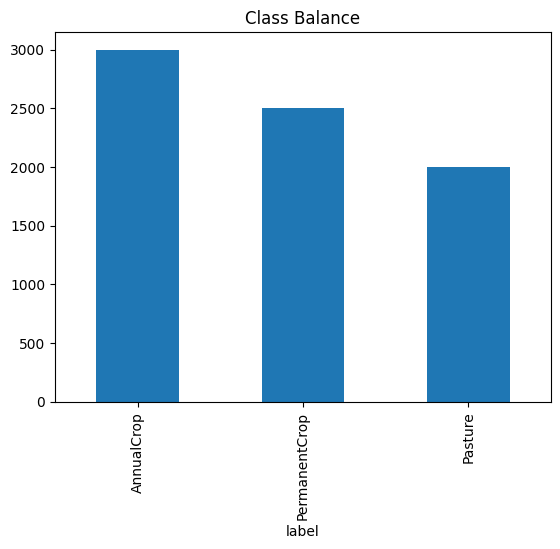

In [6]:
import os

df.label.value_counts().plot(kind="bar")
plt.title("Class Balance")

# Save the plot as a PDF
output_dir = "results/class_imbalance"
os.makedirs(output_dir, exist_ok=True)

pdf_filepath = os.path.join(output_dir, "class_balance_before_cleaning.pdf")
plt.savefig(pdf_filepath, format="pdf")
print(f"Class balance plot saved to: {pdf_filepath}")

plt.show()

**Data Prepocessing / Cleaning**

In [7]:

records=[]

for cls in sorted(os.listdir(DATASET_DIR)):
    path=os.path.join(DATASET_DIR,cls)
    if os.path.isdir(path):
        for f in os.listdir(path):
            records.append([os.path.join(path,f),cls])

df=pd.DataFrame(records,columns=["filepath","label"])

# remove corrupted
valid=[]
for fp in df.filepath:
    try:
        Image.open(fp).verify()
        valid.append(True)
    except:
        valid.append(False)

df=df[valid].reset_index(drop=True)

# remove duplicates
seen=set()
keep=[]

for fp in df.filepath:
    with open(fp,"rb") as f:
        h=hashlib.md5(f.read()).hexdigest()

    keep.append(h not in seen)
    seen.add(h)

df=df[keep].reset_index(drop=True)

# remove blurry images
def blurry(fp, threshold=50):
    img=cv2.imread(fp)
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray,cv2.CV_64F).var() < threshold

df=df[~df.filepath.apply(blurry)].reset_index(drop=True)


**Dataset Description**

In [8]:
print(df.label.value_counts())

label
AnnualCrop       2649
PermanentCrop    2491
Pasture          1626
Name: count, dtype: int64


Class balance plot saved to: results/class_imbalance/class_balance_after_cleaning.pdf


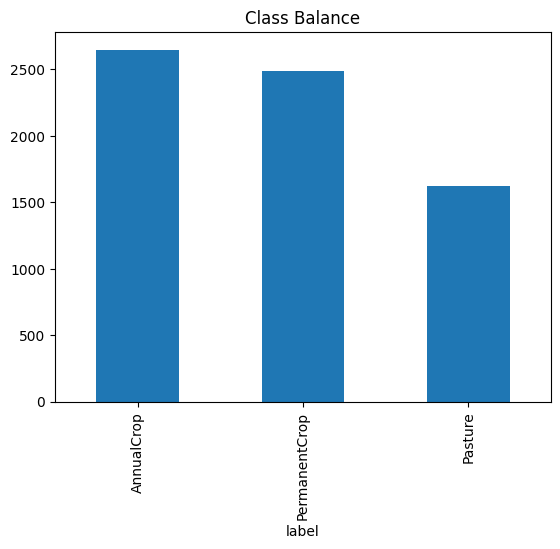

In [9]:
import os

df.label.value_counts().plot(kind="bar")
plt.title("Class Balance")

# Save the plot as a PDF
output_dir = "results/class_imbalance"
os.makedirs(output_dir, exist_ok=True)

pdf_filepath = os.path.join(output_dir, "class_balance_after_cleaning.pdf")
plt.savefig(pdf_filepath, format="pdf")
print(f"Class balance plot saved to: {pdf_filepath}")

plt.show()

**Train / Validation / Test Split**

In [10]:

train_df,test_df=train_test_split(
    df,
    test_size=0.15,
    stratify=df.label,
    random_state=SEED
)

train_df,val_df=train_test_split(
    train_df,
    test_size=0.1765,
    stratify=train_df.label,
    random_state=SEED
)

print(len(train_df),len(val_df),len(test_df))


4735 1016 1015


**Image Resizing, Normalization and Data Augmentation**

In [ ]:

train_datagen=tf.keras.preprocessing.image.ImageDataGenerator(
    # Normalization
    rescale=1./255,

    # Geometric augmentations
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,

    # Radiometric augmentation
    brightness_range=[0.8,1.2],

    channel_shift_range=10
)

test_datagen=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_gen=train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE, # Resizing
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen=test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE, # Resizing
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen=test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE, # Resizing
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 4735 validated image filenames belonging to 3 classes.
Found 1016 validated image filenames belonging to 3 classes.
Found 1015 validated image filenames belonging to 3 classes.


**Model Development**

In [ ]:

callbacks=[
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=3,
        factor=0.2
    )
]

NUM_CLASSES=len(train_gen.class_indices)

def build_custom_cnn():
    model=tf.keras.Sequential([
        tf.keras.layers.Conv2D(32,3,activation='relu',
            input_shape=(224,224,3)),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128,3,activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128,activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES,activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_transfer(base):
    base.trainable=False

    x=tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x=tf.keras.layers.Dense(256,activation='relu')(x)
    x=tf.keras.layers.Dropout(0.4)(x)
    out=tf.keras.layers.Dense(NUM_CLASSES,activation='softmax')(x)

    model=tf.keras.Model(base.input,out)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:

custom=build_custom_cnn()

mobilenet=build_transfer(
    tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )
)

resnet=build_transfer(
    tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )
)

efficientnet=build_transfer(
    tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Model Training**

In [ ]:

models={
    "CustomCNN":custom,
    "MobileNetV2":mobilenet,
    "ResNet50":resnet,
    "EfficientNetB0":efficientnet
}

histories={}

for name,model in models.items():
    print("\nTraining",name)

    histories[name]=model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        callbacks=callbacks
    )



Training CustomCNN
Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 83s 508ms/step - accuracy: 0.6061 - loss: 0.7566 - val_accuracy: 0.7303 - val_loss: 0.5918 - learning_rate: 0.0010
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 68s 459ms/step - accuracy: 0.7516 - loss: 0.5849 - val_accuracy: 0.7756 - val_loss: 0.5294 - learning_rate: 0.0010
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 67s 451ms/step - accuracy: 0.7679 - loss: 0.5473 - val_accuracy: 0.7825 - val_loss: 0.5215 - learning_rate: 0.0010
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 67s 454ms/step - accuracy: 0.7823 - loss: 0.5346 - val_accuracy: 0.7825 - val_loss: 0.5072 - learning_rate: 0.0010
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 81s 449ms/step - accuracy: 0.7949 - loss: 0.5157 - val_accuracy: 0.8209 - val_loss: 0.4551 - learning_rate: 0.0010
Epoch 6/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 67s 451ms/step - accuracy: 0.7903 - loss: 0.5205 - val_accuracy: 0.7992 - val_loss: 0.4858 - learning_rate: 0.0010
Epoch 7/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 67s 453ms/

**Model Evaluation**

Classification report and
comparison with other transfer learning models

In [ ]:

results=[]

for name,model in models.items():

    start=time.time()
    probs=model.predict(test_gen)
    elapsed=(time.time()-start)/len(test_df)

    y_true=test_gen.classes
    y_pred=np.argmax(probs,axis=1)

    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_true,y_pred),
        "Precision":precision_score(y_true,y_pred,average="weighted"),
        "Recall":recall_score(y_true,y_pred,average="weighted"),
        "F1":f1_score(y_true,y_pred,average="weighted"),
        "ROC_AUC":roc_auc_score(
            tf.keras.utils.to_categorical(y_true,NUM_CLASSES),
            probs,
            multi_class="ovr"
        ),
        "Inference_Time_sec":elapsed
    })

    print(name)
    print(classification_report(y_true,y_pred))

results_df=pd.DataFrame(results)
results_df.sort_values("Accuracy",ascending=False)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step
CustomCNN
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       397
           1       0.84      0.84      0.84       244
           2       0.83      0.85      0.84       374

    accuracy                           0.85      1015
   macro avg       0.85      0.85      0.85      1015
weighted avg       0.85      0.85      0.85      1015

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 439ms/step
MobileNetV2
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       397
           1       0.96      0.94      0.95       244
           2       0.93      0.94      0.94       374

    accuracy                           0.94      1015
   macro avg       0.95      0.94      0.94      1015
weighted avg       0.94      0.94      0.94      1015

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 261ms/step
ResNet50
              precision    recall  f1-score   support

           0       0.39     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 404ms/step
EfficientNetB0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       397
           1       0.00      0.00      0.00       244
           2       0.37      1.00      0.54       374

    accuracy                           0.37      1015
   macro avg       0.12      0.33      0.18      1015
weighted avg       0.14      0.37      0.20      1015



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Inference_Time_sec
1,MobileNetV2,0.943842,0.943998,0.943842,0.943881,0.992606,0.017953
0,CustomCNN,0.848276,0.848624,0.848276,0.848380,0.956188,0.002672
2,ResNet50,0.391133,0.152985,0.391133,0.219943,0.775447,0.012804
3,EfficientNetB0,0.368473,0.135772,0.368473,0.198429,0.666656,0.019756


In [ ]:
import matplotlib.pyplot as plt
import os

# Create the directory if it doesn't exist
output_dir = "results/classification_report"
os.makedirs(output_dir, exist_ok=True)

# Prepare the data for plotting
# Format numeric columns to 6 decimal places
formatted_df = results_df.copy()
for col in formatted_df.columns:
    if formatted_df[col].dtype in ['float64', 'float32']:
        formatted_df[col] = formatted_df[col].apply(lambda x: f'{x:.6f}')
data = formatted_df.values
columns = formatted_df.columns

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(12, 4)) # Adjust figure size as needed
ax.axis('off') # Hide the axes
ax.axis('tight') # Adjust layout to fit table

# Create the table and add it to the axes
table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2) # Scale table to improve readability

# Save the table as a PDF
pdf_filepath = os.path.join(output_dir, "classification_report.pdf")
plt.savefig(pdf_filepath, bbox_inches='tight', dpi=300)

plt.close(fig) # Close the figure to avoid displaying it unnecessarily

print(f"Classification report saved to: {pdf_filepath}")

Classification report saved to: results/classification_report/classification_report.pdf


**Save the trained model**

Persist the best performing model to disk

In [ ]:
best_name=results_df.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]["Model"]

best_model=models[best_name]

best_model.save("results/crop_classifier.keras")

import json
class_indices = train_gen.class_indices  # e.g. {'AnnualCrop':0,'Pasture':1,'PermanentCrop':2}
idx_to_class = {v: k for k, v in class_indices.items()}
with open("class_indices.json", "w") as f:
    json.dump(idx_to_class, f)

**Confusion Matrix**

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Confusion matrix saved to: results/confusion_matrix/confusion_matrix.pdf


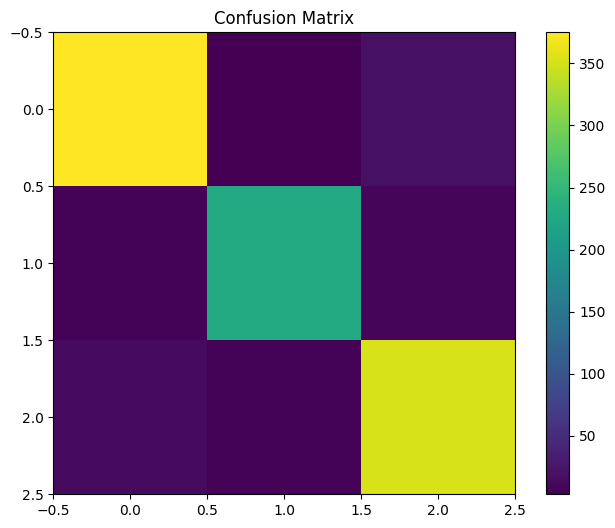

In [ ]:

best_name=results_df.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]["Model"]

best_model=models[best_name]

preds=best_model.predict(test_gen)
y_pred=np.argmax(preds,axis=1)

cm=confusion_matrix(test_gen.classes,y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

# Save the plot as a PDF
output_dir = "results/confusion_matrix"
os.makedirs(output_dir, exist_ok=True)

pdf_filepath = os.path.join(output_dir, "confusion_matrix.pdf")
plt.savefig(pdf_filepath, format="pdf")
print(f"Confusion matrix saved to: {pdf_filepath}")

plt.show()


**Accuracy / Loss Curves**

CustomCNN saved to: results/accuracy_loss_curves/accuracy/CustomCNN.pdf


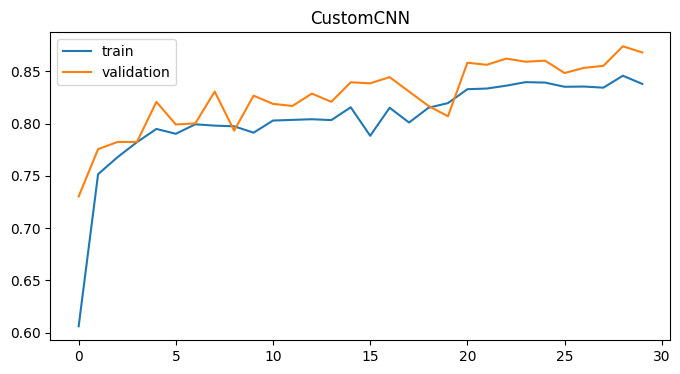

MobileNetV2 saved to: results/accuracy_loss_curves/accuracy/MobileNetV2.pdf


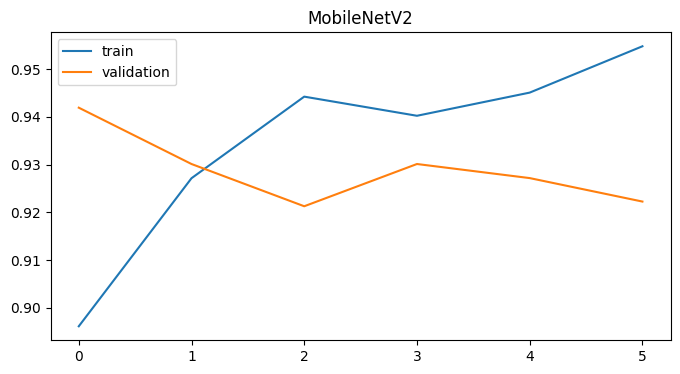

ResNet50 saved to: results/accuracy_loss_curves/accuracy/ResNet50.pdf


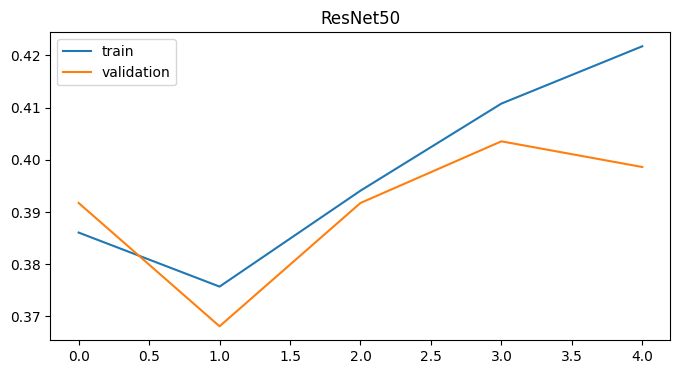

EfficientNetB0 saved to: results/accuracy_loss_curves/accuracy/EfficientNetB0.pdf


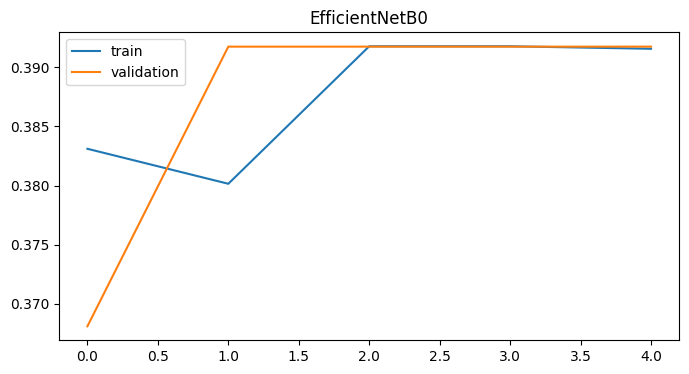

In [ ]:

for name,h in histories.items():
    plt.figure(figsize=(8,4))
    plt.plot(h.history["accuracy"])
    plt.plot(h.history["val_accuracy"])
    plt.title(name)
    plt.legend(["train","validation"])

    # Save the plot as a PDF
    output_dir = "results/accuracy_loss_curves/accuracy"
    os.makedirs(output_dir, exist_ok=True)

    pdf_filepath = os.path.join(output_dir, name + ".pdf")
    plt.savefig(pdf_filepath, format="pdf")
    print(f"{name} saved to: {pdf_filepath}")

    plt.show()


CustomCNN saved to: results/accuracy_loss_curves/loss/CustomCNN.pdf


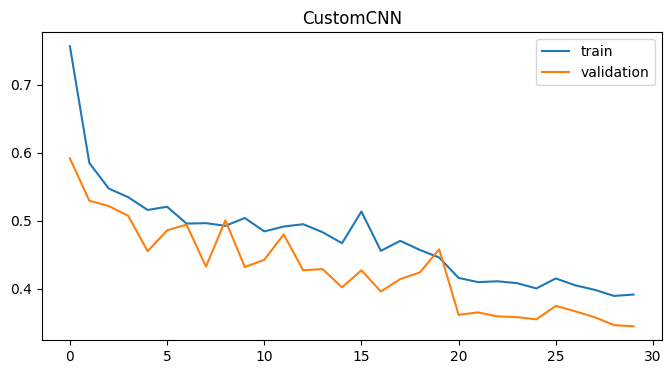

MobileNetV2 saved to: results/accuracy_loss_curves/loss/MobileNetV2.pdf


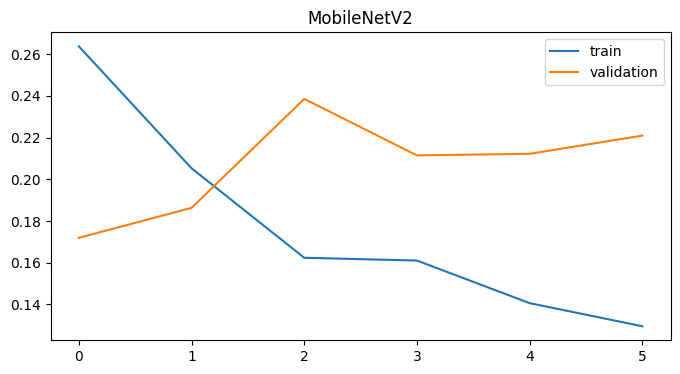

ResNet50 saved to: results/accuracy_loss_curves/loss/ResNet50.pdf


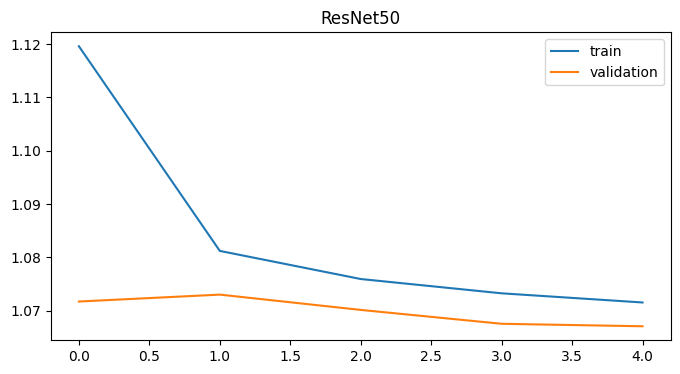

EfficientNetB0 saved to: results/accuracy_loss_curves/loss/EfficientNetB0.pdf


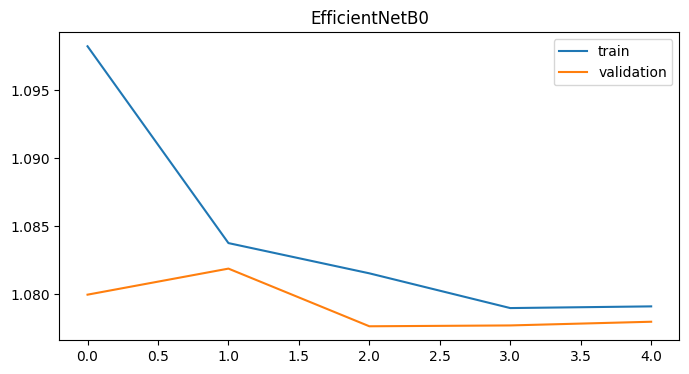

In [ ]:

for name,h in histories.items():
    plt.figure(figsize=(8,4))
    plt.plot(h.history["loss"])
    plt.plot(h.history["val_loss"])
    plt.title(name)
    plt.legend(["train","validation"])

    # Save the plot as a PDF
    output_dir = "results/accuracy_loss_curves/loss"
    os.makedirs(output_dir, exist_ok=True)

    pdf_filepath = os.path.join(output_dir, name + ".pdf")
    plt.savefig(pdf_filepath, format="pdf")
    print(f"{name} saved to: {pdf_filepath}")

    plt.show()


**ROC and Precision-Recall Curves**

ROC Class 0 saved to: results/ROC_and_precision_recall_curves/ROC/ROC_class_0.pdf


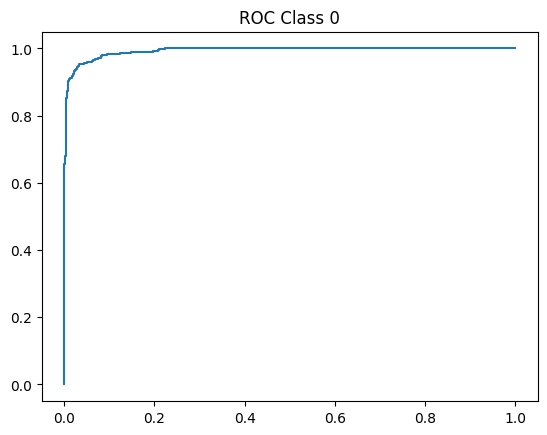

PR Curve Class 0 saved to: results/ROC_and_precision_recall_curves/precision_recall_curves/PR_curve_class_0.pdf


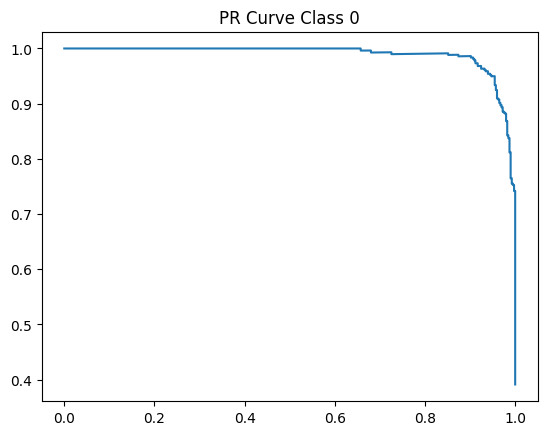

ROC Class 1 saved to: results/ROC_and_precision_recall_curves/ROC/ROC_class_1.pdf


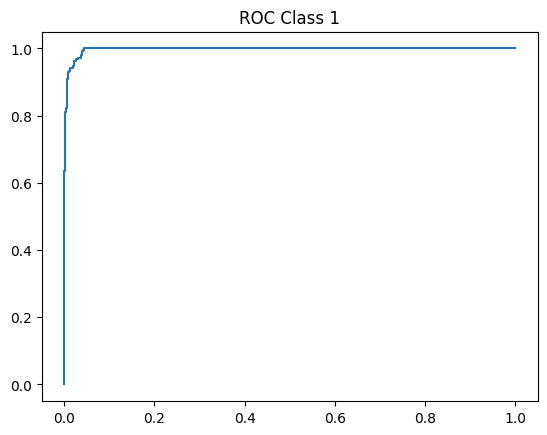

PR Curve Class 1 saved to: results/ROC_and_precision_recall_curves/precision_recall_curves/PR_curve_class_1.pdf


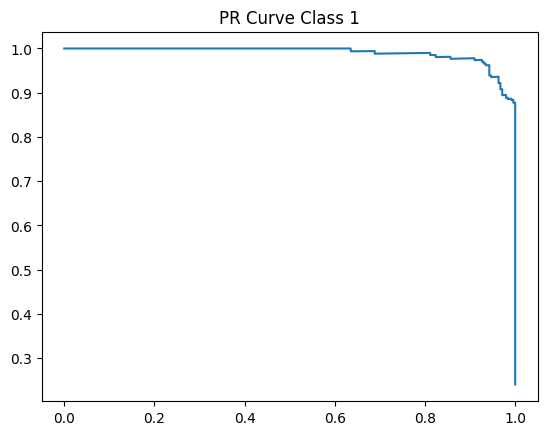

ROC Class 2 saved to: results/ROC_and_precision_recall_curves/ROC/ROC_class_2.pdf


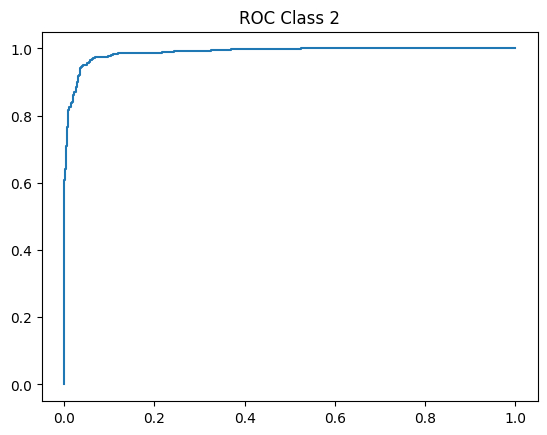

PR Curve Class 2 saved to: results/ROC_and_precision_recall_curves/precision_recall_curves/PR_curve_class_2.pdf


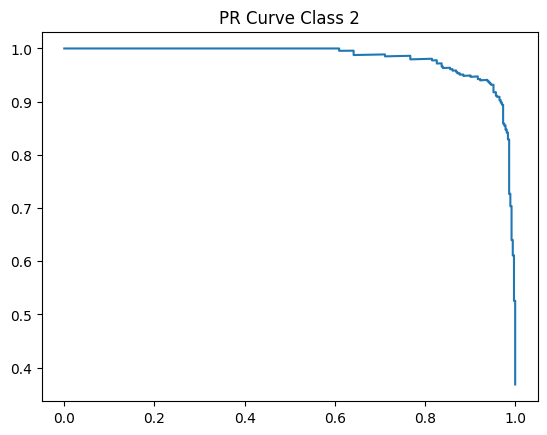

In [ ]:

y_true=tf.keras.utils.to_categorical(
    test_gen.classes,
    NUM_CLASSES
)

for c in range(NUM_CLASSES):
    fpr,tpr,_=roc_curve(y_true[:,c],preds[:,c])
    plt.figure()
    plt.plot(fpr,tpr)
    plt.title(f"ROC Class {c}")

    # Save the plot as a PDF
    output_dir = "results/ROC_and_precision_recall_curves/ROC"
    os.makedirs(output_dir, exist_ok=True)

    pdf_filepath = os.path.join(output_dir, "ROC_class_" + str(c) + ".pdf")
    plt.savefig(pdf_filepath, format="pdf")
    print(f"ROC Class {c} saved to: {pdf_filepath}")

    plt.show()

    p,r,_=precision_recall_curve(
        y_true[:,c],
        preds[:,c]
    )
    plt.figure()
    plt.plot(r,p)
    plt.title(f"PR Curve Class {c}")

    # Save the plot as a PDF
    output_dir = "results/ROC_and_precision_recall_curves/precision_recall_curves"
    os.makedirs(output_dir, exist_ok=True)

    pdf_filepath = os.path.join(output_dir, "PR_curve_class_" + str(c) + ".pdf")
    plt.savefig(pdf_filepath, format="pdf")
    print(f"PR Curve Class {c} saved to: {pdf_filepath}")

    plt.show()


**Grad-CAM Explainability**

In [ ]:

def gradcam(model, img, layer_name):

    grad_model=tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output,
         model.output]
    )

    with tf.GradientTape() as tape:
        conv,preds=grad_model(img)
        idx=tf.argmax(preds[0])
        loss=preds[:,idx]

    grads=tape.gradient(loss,conv)
    pooled=tf.reduce_mean(grads,axis=(0,1,2))

    conv=conv[0]
    heatmap=conv @ pooled[...,None]
    heatmap=tf.squeeze(heatmap)

    heatmap=np.maximum(heatmap,0)
    heatmap/=heatmap.max()

    return heatmap

os.makedirs("results/correct_predictions",exist_ok=True)
os.makedirs("results/false_positives",exist_ok=True)
os.makedirs("results/false_negatives",exist_ok=True)


In [ ]:
# First, identify the last convolutional layer of the best model dynamically.
last_conv_layer_name = None
for layer in reversed(best_model.layers):
    # Look for Conv2D or DepthwiseConv2D layers as they are common in CNNs and MobileNetV2
    if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)):
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name is None:
    print("Could not find a convolutional layer in the best model. Please check the model architecture.")
else:
    print(f"Last convolutional layer for {best_name}: {last_conv_layer_name}")

# Get class names from the training generator
class_names = list(train_gen.class_indices.keys())

# Prepare lists to store indices of correctly classified and misclassified images
correct_indices = []
misclassified_indices = []

# Populate these lists by comparing true labels with predicted labels from the test set
for i in range(len(test_df)): # Iterate through each image in the test set
    true_label_idx = test_gen.classes[i] # True label index
    predicted_label_idx = y_pred[i]     # Predicted label index (from previous cell's output)

    if true_label_idx == predicted_label_idx:
        correct_indices.append(i)
    else:
        misclassified_indices.append(i)

# Define a function to process and save Grad-CAM images
def process_and_save_gradcam_samples(indices_to_process, category_name, num_samples_to_save=5):
    # Randomly select a subset of indices to process, up to num_samples_to_save
    selected_indices = np.random.choice(
        indices_to_process,
        min(num_samples_to_save, len(indices_to_process)),
        replace=False
    )

    for i in selected_indices:
        filepath = test_df.iloc[i]['filepath']
        true_label_idx = test_gen.classes[i]
        predicted_label_idx = y_pred[i]

        try:
            # Load and preprocess the original image
            original_img = cv2.imread(filepath)
            original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
            original_img_resized = cv2.resize(original_img, IMG_SIZE)

            # Prepare image for model input and Grad-CAM generation
            img_tensor = tf.keras.preprocessing.image.load_img(filepath, target_size=IMG_SIZE)
            img_array = tf.keras.preprocessing.image.img_to_array(img_tensor)
            img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
            img_array = img_array / 255.0 # Rescale pixels to [0, 1]

            # Generate Grad-CAM heatmap
            heatmap = gradcam(best_model, img_array, last_conv_layer_name)

            # Apply colormap to heatmap and resize to original image dimensions
            heatmap = np.uint8(255 * heatmap)
            jet = plt.colormaps["jet"]
            jet_colors = jet(np.arange(256))[:, :3] # Get RGB values from colormap
            jet_heatmap = jet_colors[heatmap]

            jet_heatmap_pil = Image.fromarray(np.uint8(jet_heatmap * 255))
            jet_heatmap_pil = jet_heatmap_pil.resize((original_img_resized.shape[1], original_img_resized.shape[0]))
            jet_heatmap = np.array(jet_heatmap_pil) / 255.0 # Convert back to 0-1 for blending

            # Superimpose heatmap on the original resized image
            superimposed_img = jet_heatmap * 0.4 + original_img_resized / 255.0 # 0.4 opacity for heatmap
            superimposed_img = np.uint8(255 * superimposed_img) # Scale back to 0-255 for saving

            # Get class names for informative filenames
            true_class_name = class_names[true_label_idx]
            predicted_class_name = class_names[predicted_label_idx]
            filename_base = os.path.basename(filepath).split('.')[0]

            # Define save directory and ensure it exists
            save_dir = os.path.join("results", category_name)
            os.makedirs(save_dir, exist_ok=True)

            # Save original and superimposed (Grad-CAM) images
            Image.fromarray(original_img_resized).save(
                os.path.join(save_dir, f"{filename_base}_original_true_{true_class_name}_pred_{predicted_class_name}.jpg")
            )
            Image.fromarray(superimposed_img).save(
                os.path.join(save_dir, f"{filename_base}_gradcam_true_{true_class_name}_pred_{predicted_class_name}.jpg")
            )
            print(f"Saved {category_name} example: {filename_base}")

        except Exception as e:
            print(f"Error processing image {filepath} for {category_name}: {e}")

# Define the number of samples to save
NUM_SAMPLES_TO_SAVE = 5

# Process and save Grad-CAM for correct predictions
print(f"\nGenerating Grad-CAM for {min(NUM_SAMPLES_TO_SAVE, len(correct_indices))} correct predictions...")
process_and_save_gradcam_samples(correct_indices, "correct_predictions", num_samples_to_save=NUM_SAMPLES_TO_SAVE)

# Process and save Grad-CAM for misclassified predictions
print(f"\nGenerating Grad-CAM for {min(NUM_SAMPLES_TO_SAVE, len(misclassified_indices))} misclassified predictions...")
# Using 'false_positives' folder for general misclassified images
process_and_save_gradcam_samples(misclassified_indices, "false_positives", num_samples_to_save=NUM_SAMPLES_TO_SAVE)


Last convolutional layer for MobileNetV2: Conv_1

Generating Grad-CAM for 5 correct predictions...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_10']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Saved correct_predictions example: AnnualCrop_1915
Saved correct_predictions example: AnnualCrop_1894
Saved correct_predictions example: PermanentCrop_373
Saved correct_predictions example: PermanentCrop_1549
Saved correct_predictions example: Pasture_279

Generating Grad-CAM for 5 misclassified predictions...
Saved false_positives example: PermanentCrop_2337
Saved false_positives example: AnnualCrop_1534
Saved false_positives example: PermanentCrop_2268
Saved false_positives example: PermanentCrop_315
Saved false_positives example: Pasture_1905


**Zip and download results folder**

In [ ]:
import shutil
from google.colab import files

# Create a zip archive of the results folder
archive_name = 'results_archive'
output_filename = shutil.make_archive(archive_name, 'zip', 'results')

print(f"Created archive: {output_filename}")

# Download the zip file
files.download(output_filename)

Created archive: /content/results_archive.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>